In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

YEAR_FILTER = '0113-2'  # 修改為你想篩選的年份

INPUT_FOLDER = f'processed_data_{YEAR_FILTER}/'  # 資料夾路徑
PREDICT_FOLDER = f'predicted_results_{YEAR_FILTER}/'  # 預測結果的資料夾
OUTPUT_FOLDER = f'filtered_courses_{YEAR_FILTER}/'  # 篩選後的輸出資料夾
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def filter_113_files_and_update_predictions(input_folder, predict_folder, output_folder):
    """讀取結尾是 113-1.csv 的檔案，並只保留課程名稱、選課人數和餘額三個欄位，同時刪除選課人數為 0 的資料及其對應的預測結果"""
    for file in os.listdir(input_folder):
        if file.endswith(f'{YEAR_FILTER}.csv'):  # 篩選以 113-1.csv 結尾的檔案
            file_path = os.path.join(input_folder, file)
            print(f"處理檔案: {file_path}")
            
            # 讀取 CSV
            df = pd.read_csv(file_path)

            # 確認所需欄位是否存在
            if '科目名稱(連結課程地圖)             備註 \n             限選條件' in df.columns and '已選課人數/餘額' in df.columns:
                # 分割選課人數/餘額，保留選課人數和餘額
                df[['選課人數', '餘額']] = df['已選課人數/餘額'].str.split('/', expand=True)
                # 將選課人數和餘額轉換為數字，並補空白為 0
                df['選課人數'] = pd.to_numeric(df['選課人數'], errors='coerce').fillna(0).astype(int)
                df['餘額'] = pd.to_numeric(df['餘額'], errors='coerce').fillna(0).astype(int)

                # 保留指定欄位
                filtered_df = df[['科目名稱(連結課程地圖)             備註 \n             限選條件', '選課人數', '餘額']].copy()
                filtered_df.rename(columns={
                    '科目名稱(連結課程地圖)             備註 \n             限選條件': '科目名稱',
                    '選課人數': '已選人數',
                    '餘額': '剩餘名額'
                }, inplace=True)

                # 刪除選課人數為 0 的資料
                before_drop_count = len(filtered_df)
                dropped_courses = filtered_df[filtered_df['已選人數'] == 0]['科目名稱'].tolist()
                filtered_df = filtered_df[filtered_df['已選人數'] != 0]
                after_drop_count = len(filtered_df)

                if before_drop_count != after_drop_count:
                    print(f"檔案 {file} 中刪除了 {before_drop_count - after_drop_count} 筆選課人數為 0 的資料")

                # 儲存篩選後的檔案
                output_file = os.path.join(output_folder, file)
                filtered_df.to_csv(output_file, index=False, encoding='utf-8')
                print(f"已儲存篩選後的檔案至 {output_file}")

                # 刪除預測結果中的對應條目
                predict_file = os.path.join(predict_folder, f"{file.split('_')[0]}_predictions.csv")
                if os.path.exists(predict_file):
                    predict_df = pd.read_csv(predict_file)
                    predict_before_drop_count = len(predict_df)
                    predict_df = predict_df[~predict_df['科目名稱'].isin(dropped_courses)]
                    predict_after_drop_count = len(predict_df)

                    if predict_before_drop_count != predict_after_drop_count:
                        print(f"預測檔案 {predict_file} 中刪除了 {predict_before_drop_count - predict_after_drop_count} 筆對應的預測資料")
                    
                    # 儲存更新後的預測結果
                    predict_df.to_csv(predict_file, index=False, encoding='utf-8')
                else:
                    print(f"預測檔案 {predict_file} 不存在，跳過處理")
            else:
                print(f"檔案 {file} 缺少必要欄位，跳過處理")

if __name__ == '__main__':
    filter_113_files_and_update_predictions(INPUT_FOLDER, PREDICT_FOLDER, OUTPUT_FOLDER)

處理檔案: processed_data_0113-2/數學系 MATH_0113-2.csv
已儲存篩選後的檔案至 filtered_courses_0113-2/數學系 MATH_0113-2.csv
處理檔案: processed_data_0113-2/測量系 GM_0113-2.csv
已儲存篩選後的檔案至 filtered_courses_0113-2/測量系 GM_0113-2.csv
處理檔案: processed_data_0113-2/統計系 STAT_0113-2.csv
檔案 統計系 STAT_0113-2.csv 中刪除了 1 筆選課人數為 0 的資料
已儲存篩選後的檔案至 filtered_courses_0113-2/統計系 STAT_0113-2.csv
處理檔案: processed_data_0113-2/資訊系 CSIE_0113-2.csv
檔案 資訊系 CSIE_0113-2.csv 中刪除了 8 筆選課人數為 0 的資料
已儲存篩選後的檔案至 filtered_courses_0113-2/資訊系 CSIE_0113-2.csv


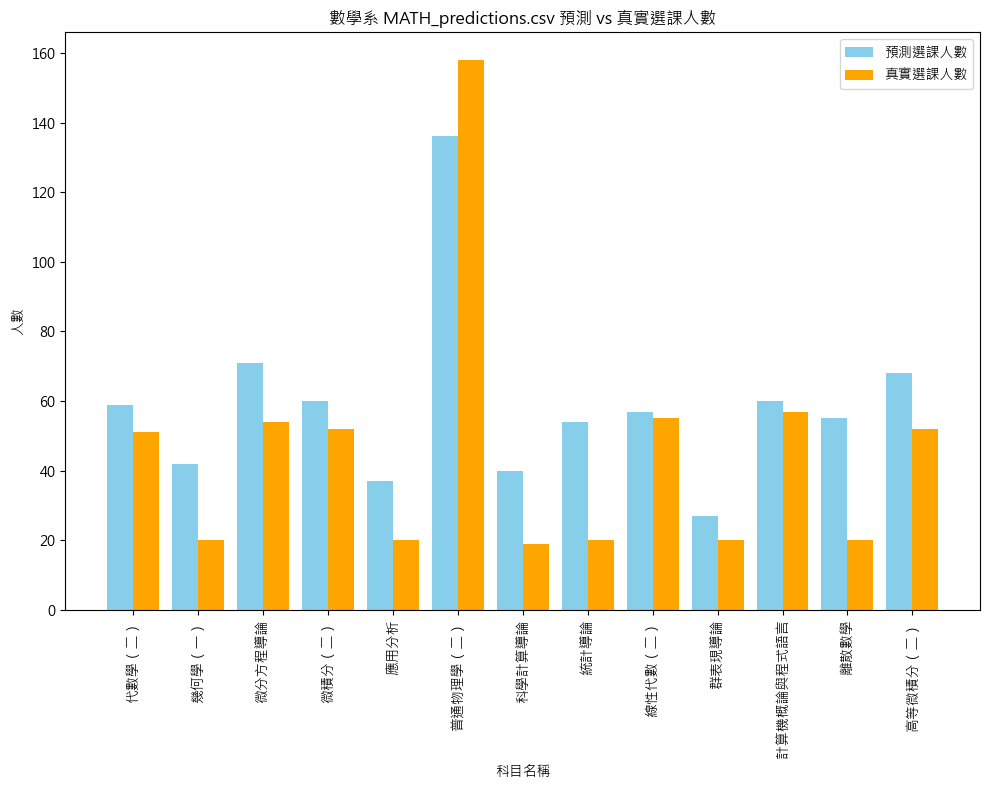

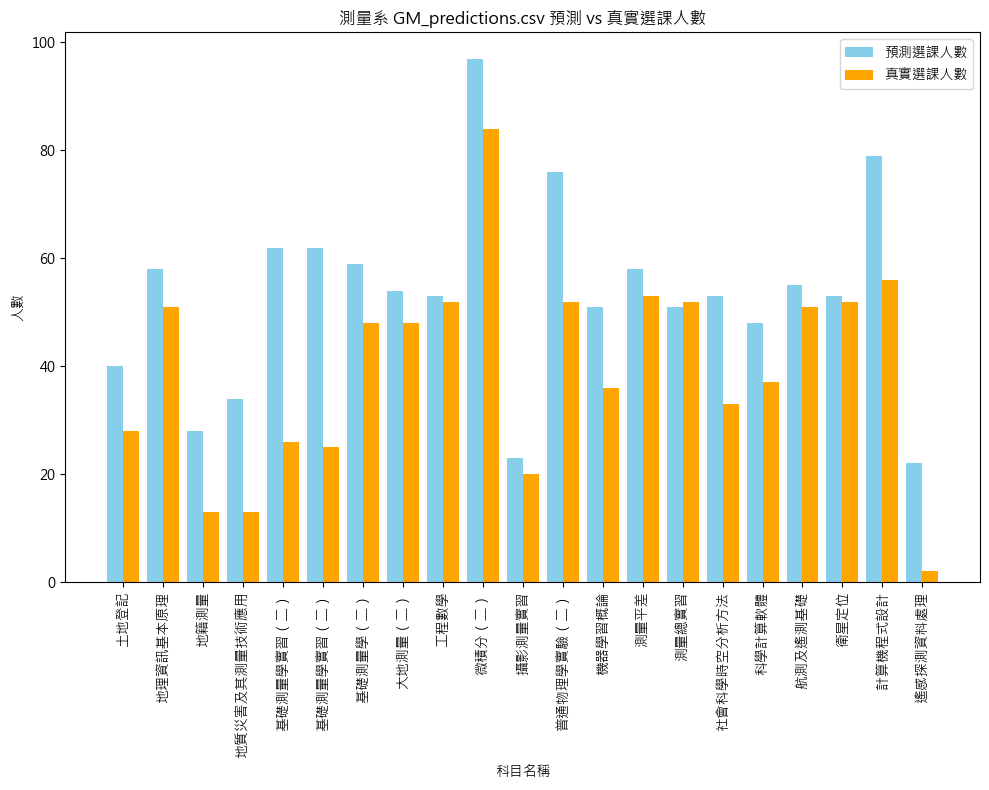

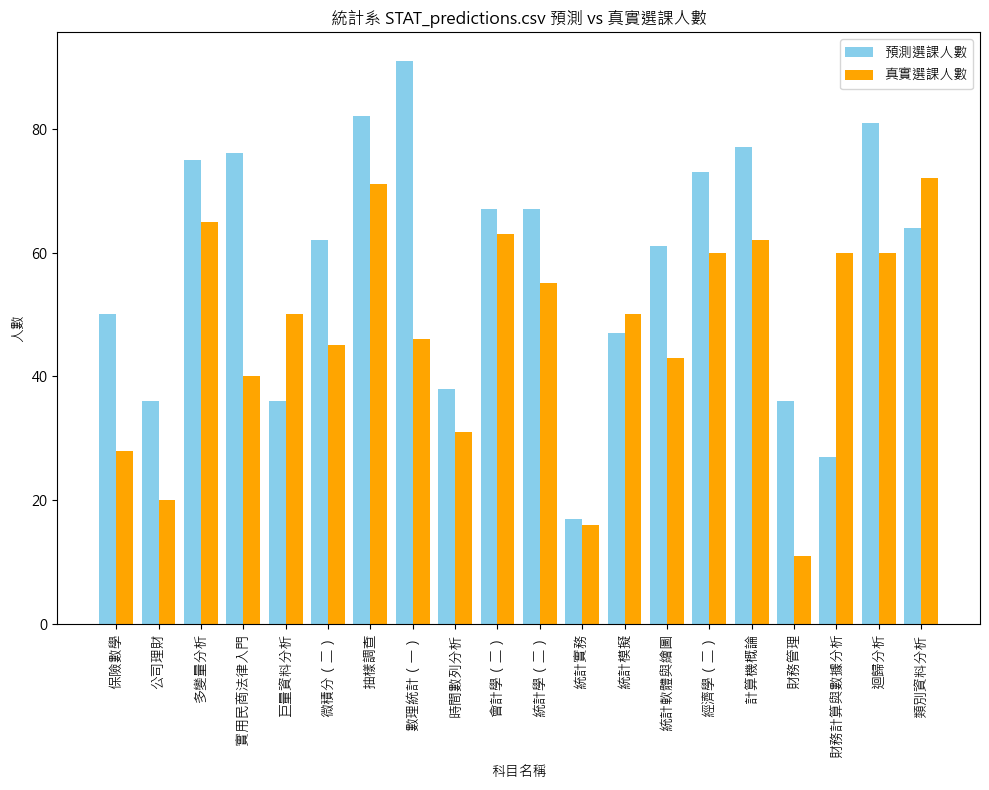

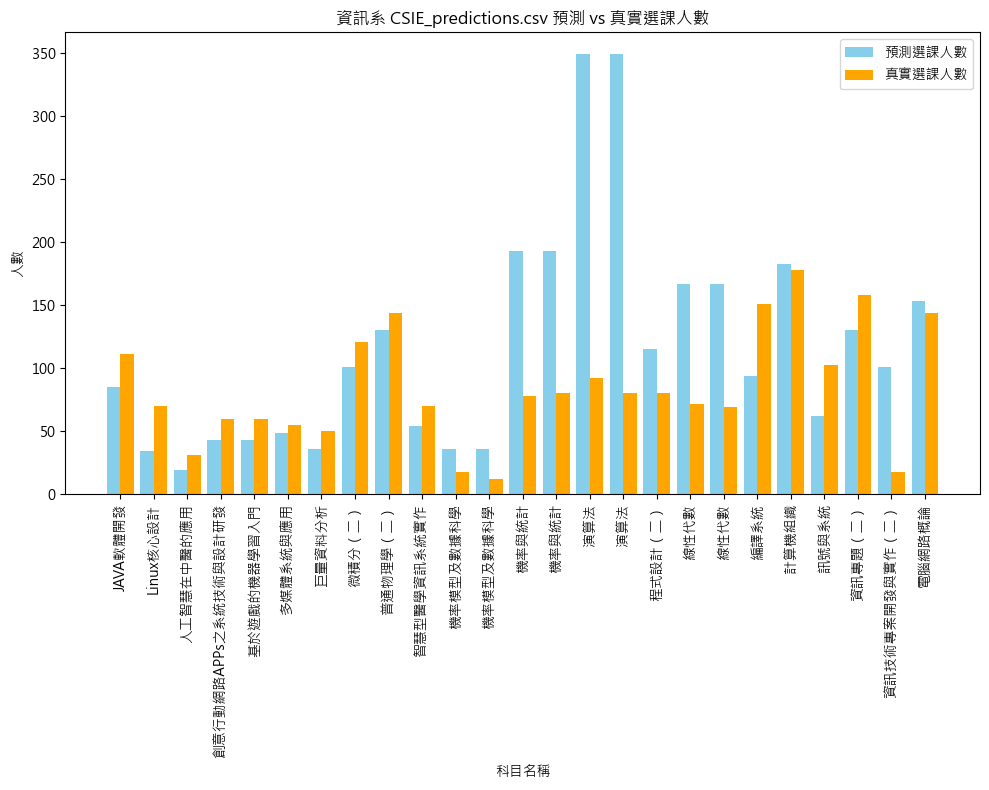

In [10]:
plt.rc("font", family="Microsoft JhengHei")  # 替換為你的字體名稱

PREDICTED_FOLDER = f'predicted_results_{YEAR_FILTER}/'  # 預測結果保存路徑
ACTUAL_FOLDER = f'filtered_courses_{YEAR_FILTER}/'  # 真實數據的資料夾

def inspect_and_plot_predictions(predicted_folder, actual_folder):
    """檢視預測結果並繪製圖表，包括真實的選課人數"""
    for file in os.listdir(predicted_folder):
        if file.endswith('_predictions.csv'):
            predicted_filepath = os.path.join(predicted_folder, file)
            predicted_df = pd.read_csv(predicted_filepath)

            # 尋找對應的真實數據檔案
            department = file.split('_')[0]
            actual_filepath = os.path.join(actual_folder, f"{department}_{YEAR_FILTER}.csv")

            if os.path.exists(actual_filepath):
                actual_df = pd.read_csv(actual_filepath)

                # 合併預測數據與真實數據
                if '科目名稱' in actual_df.columns and '已選人數' in actual_df.columns:
                    merged_df = pd.merge(
                        predicted_df,
                        actual_df[['科目名稱', '已選人數']],
                        on='科目名稱',
                        how='left'
                    )

                    # 繪製預測與真實選課人數
                    plt.figure(figsize=(10, 8))
                    bar_width = 0.4
                    x = range(len(merged_df))

                    # 預測選課人數
                    plt.bar(
                        [i - bar_width / 2 for i in x],
                        merged_df['預測選課'],
                        width=bar_width,
                        color='skyblue',
                        label='預測選課人數'
                    )

                    # 真實選課人數
                    plt.bar(
                        [i + bar_width / 2 for i in x],
                        merged_df['已選人數'],
                        width=bar_width,
                        color='orange',
                        label='真實選課人數'
                    )

                    plt.title(f"{file} 預測 vs 真實選課人數")
                    plt.xlabel('科目名稱')
                    plt.ylabel('人數')
                    plt.xticks(x, merged_df['科目名稱'], rotation=90)
                    plt.legend()
                    plt.tight_layout()
                    plt.show()
                else:
                    print(f"檔案 {actual_filepath} 缺少必要欄位，跳過繪製")
            else:
                print(f"找不到對應的真實數據檔案 {actual_filepath}")

if __name__ == '__main__':
    inspect_and_plot_predictions(PREDICTED_FOLDER, ACTUAL_FOLDER)